# Growth from Single Disk
First simulation after refactoring.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from core import (
    make_lattice,
    make_birth_kernel,
    ModelConfig,
    NoAdhesion,
    HardThresholdModifier,
    PowerLawModifier,
    BoltzmannModifier,
    CultureSimulator,
)

from lib import (
    result_to_frame,
    aggregate_results,
    fit_power_law_exponent,
    plot_observables,
    plot_ensemble_curve,
    plot_snapshots,
)

## Birth only

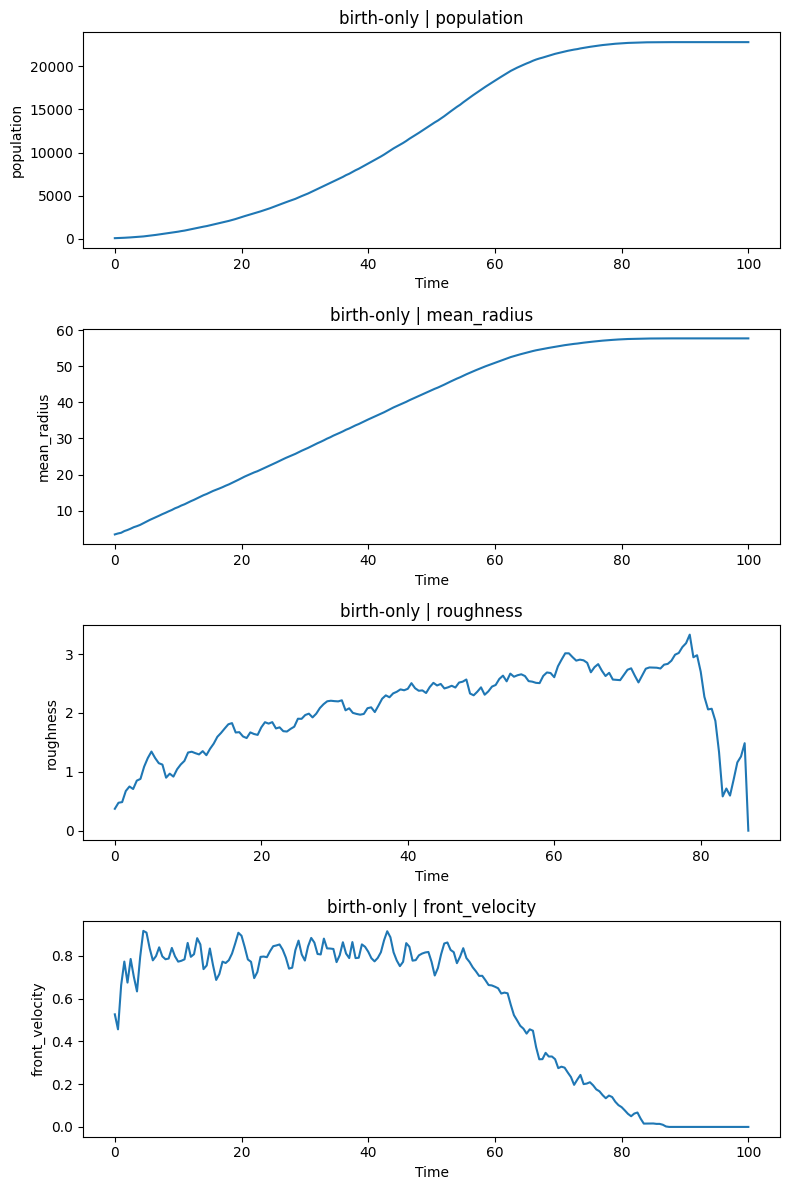

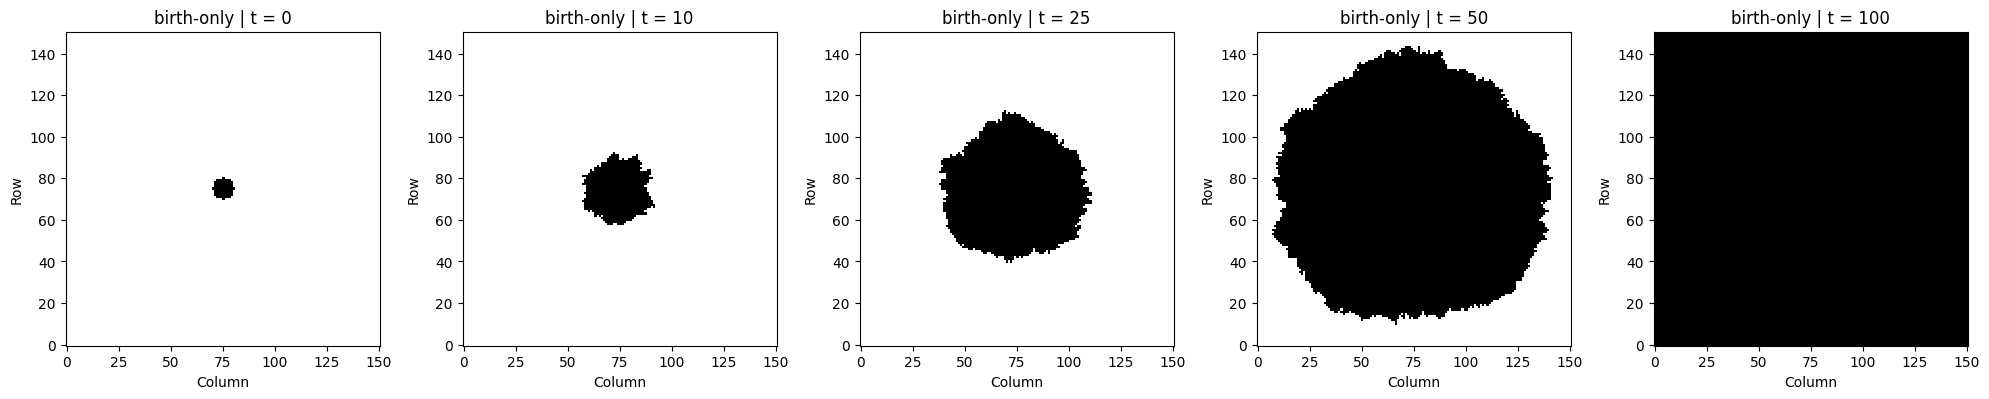

In [3]:
# ----------------------------
# Geometry and initialization
# ----------------------------
lattice = make_lattice(kind="square", nrows=151, ncols=151, periodic=False)
initial_state = lattice.make_disk_state(radius=5.0)

# ----------------------------
# Model configuration
# ----------------------------
config = ModelConfig(
    birth_kernel=make_birth_kernel("cell_driven"),
    r_birth=1.0,
    r_death=0.0,
    birth_modifier=NoAdhesion(),
    death_modifier=NoAdhesion(),
)

# ----------------------------
# Simulation
# ----------------------------
simulator = CultureSimulator(lattice=lattice)

t_final = 100.0
observation_times = np.linspace(0.0, t_final, 201)

result = simulator.run(
    initial_state=initial_state,
    config=config,
    t_final=t_final,
    rng=np.random.default_rng(12345),
    observation_times=observation_times,
    store_snapshots=True,
)

plot_observables(result, title_prefix="birth-only | ")
plot_snapshots(lattice, result, times_to_show=[0.0, 10.0, 25.0, 50.0, 100.0], title_prefix="birth-only | ")

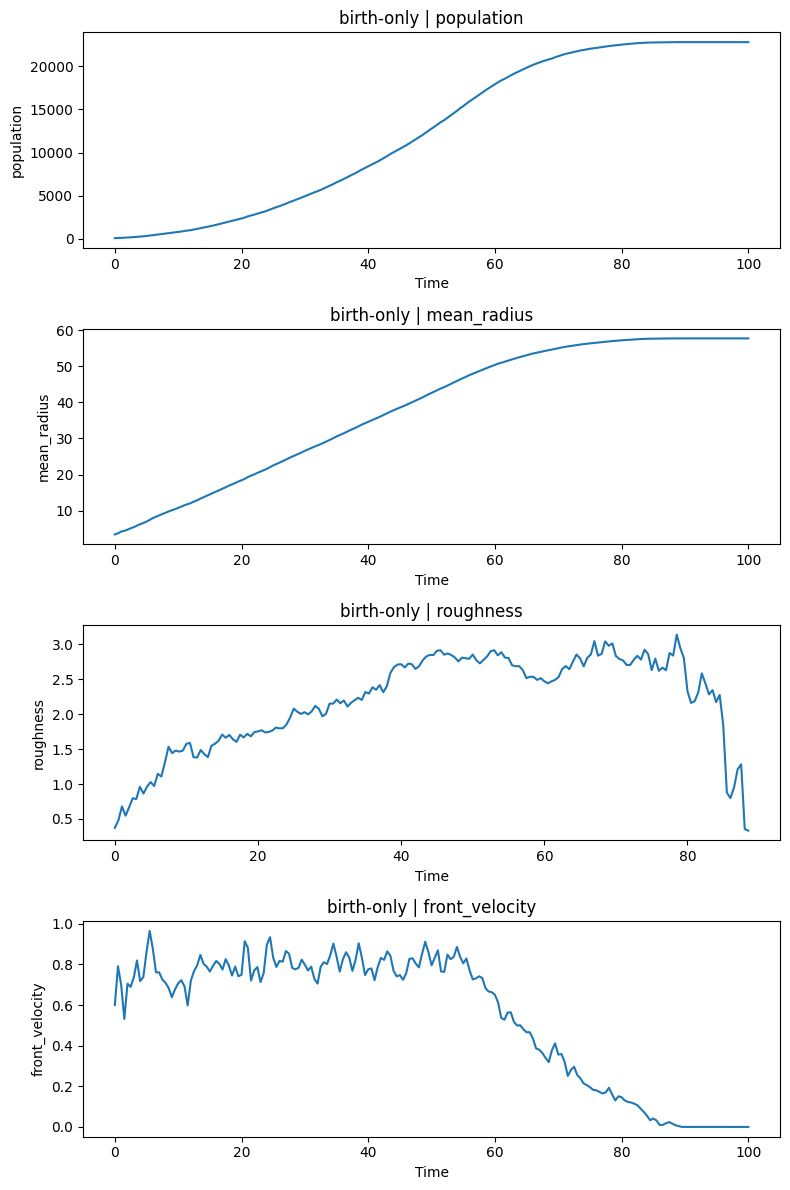

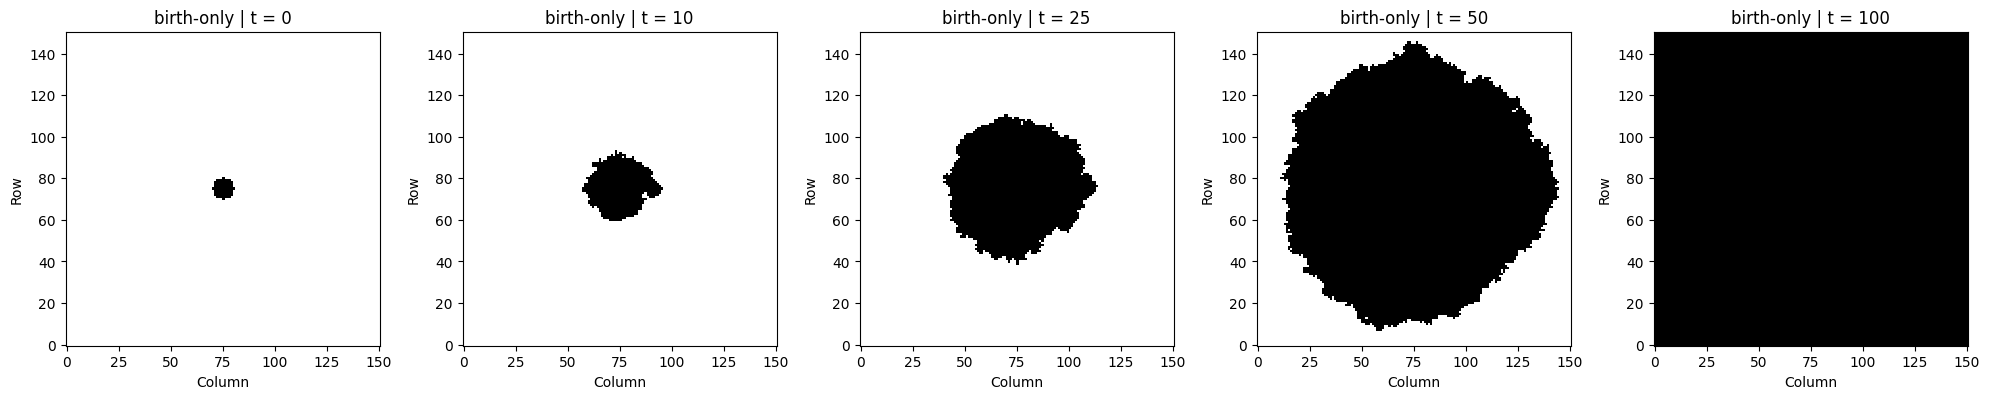

In [2]:
# ============= OPTIMIZED =============
# ----------------------------
# Geometry and initialization
# ----------------------------
lattice = make_lattice(kind="square", nrows=151, ncols=151, periodic=False)
initial_state = lattice.make_disk_state(radius=5.0)

# ----------------------------
# Model configuration
# ----------------------------
config = ModelConfig(
    birth_kernel=make_birth_kernel("cell_driven"),
    r_birth=1.0,
    r_death=0.0,
    birth_modifier=NoAdhesion(),
    death_modifier=NoAdhesion(),
)

# ----------------------------
# Simulation
# ----------------------------
simulator = CultureSimulator(lattice=lattice)

t_final = 100.0
observation_times = np.linspace(0.0, t_final, 201)

result = simulator.run(
    initial_state=initial_state,
    config=config,
    t_final=t_final,
    rng=np.random.default_rng(12345),
    observation_times=observation_times,
    store_snapshots=True,
)

plot_observables(result, title_prefix="birth-only | ")
plot_snapshots(lattice, result, times_to_show=[0.0, 10.0, 25.0, 50.0, 100.0], title_prefix="birth-only | ")

### New new

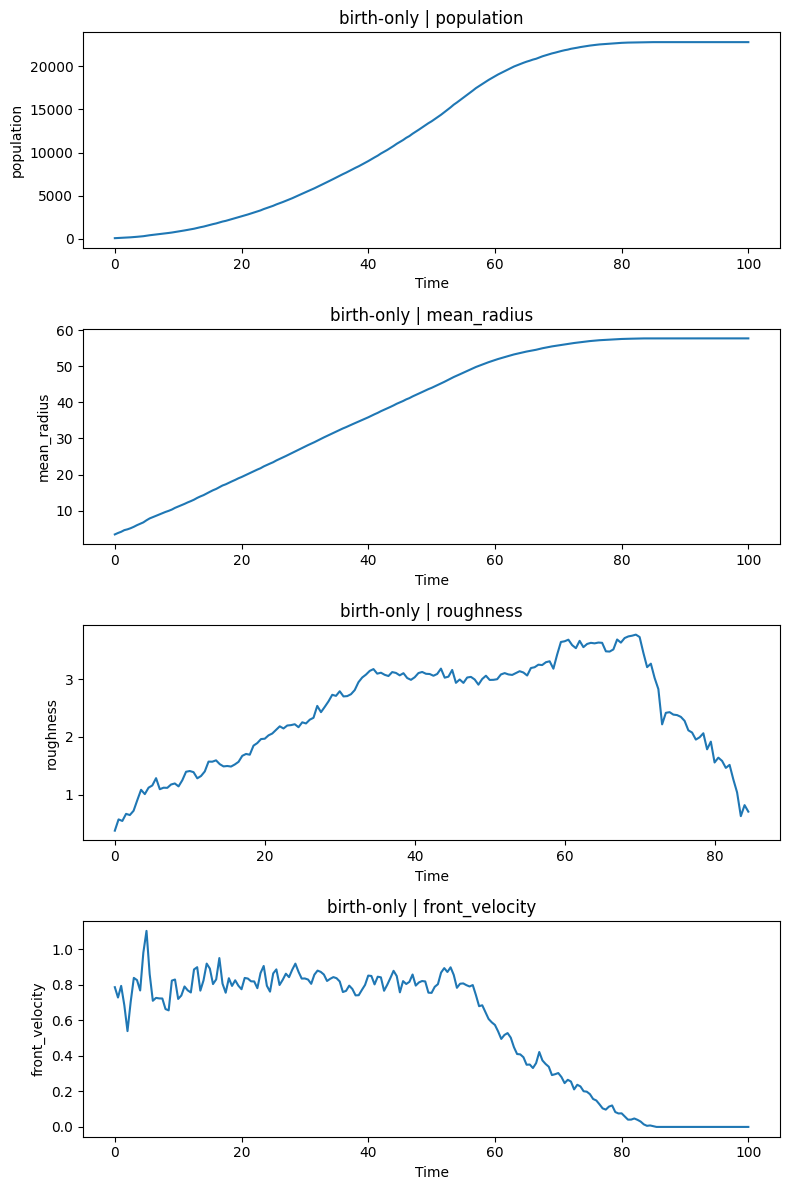

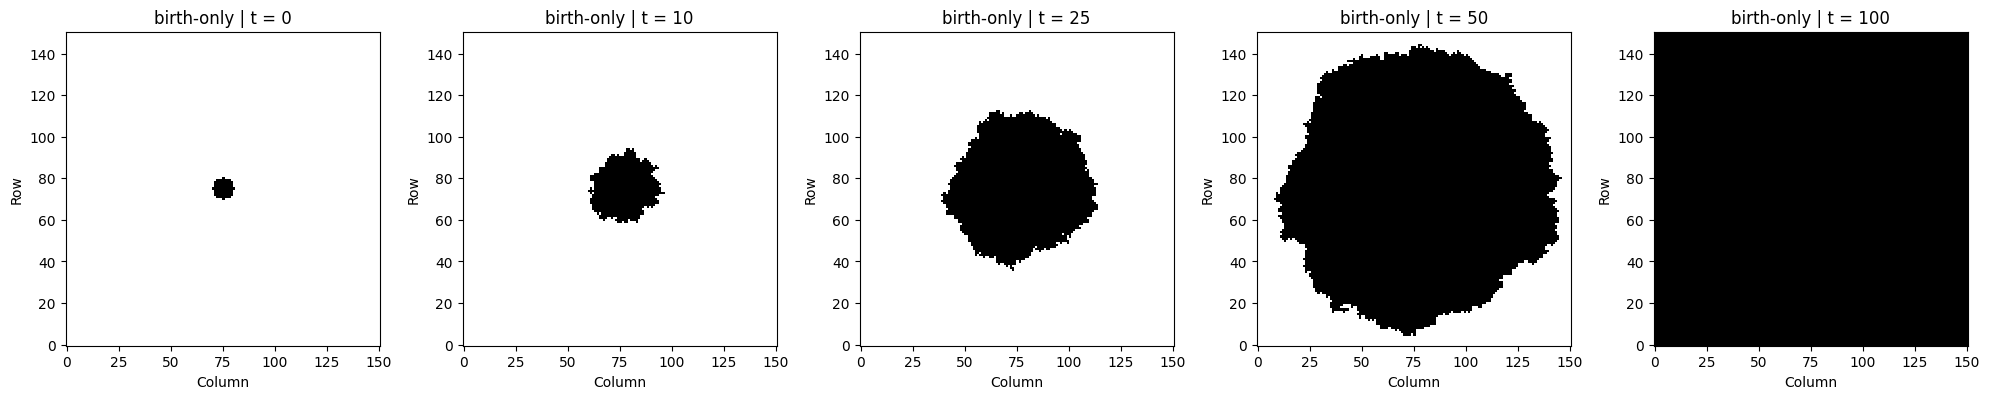

In [2]:
# ============= OPTIMIZED (NEW) =============
# ----------------------------
# Geometry and initialization
# ----------------------------
lattice = make_lattice(kind="square", nrows=151, ncols=151, periodic=False)
initial_state = lattice.make_disk_state(radius=5.0)

# ----------------------------
# Model configuration
# ----------------------------
config = ModelConfig(
    birth_kernel=make_birth_kernel("cell_driven"),
    r_birth=1.0,
    r_death=0.0,
    birth_modifier=NoAdhesion(),
    death_modifier=NoAdhesion(),
)

# ----------------------------
# Simulation
# ----------------------------
simulator = CultureSimulator(lattice=lattice)

t_final = 100.0
observation_times = np.linspace(0.0, t_final, 201)

result = simulator.run(
    initial_state=initial_state,
    config=config,
    t_final=t_final,
    rng=np.random.default_rng(12345),
    observation_times=observation_times,
    store_snapshots=True,
)

plot_observables(result, title_prefix="birth-only | ")
plot_snapshots(lattice, result, times_to_show=[0.0, 10.0, 25.0, 50.0, 100.0], title_prefix="birth-only | ")

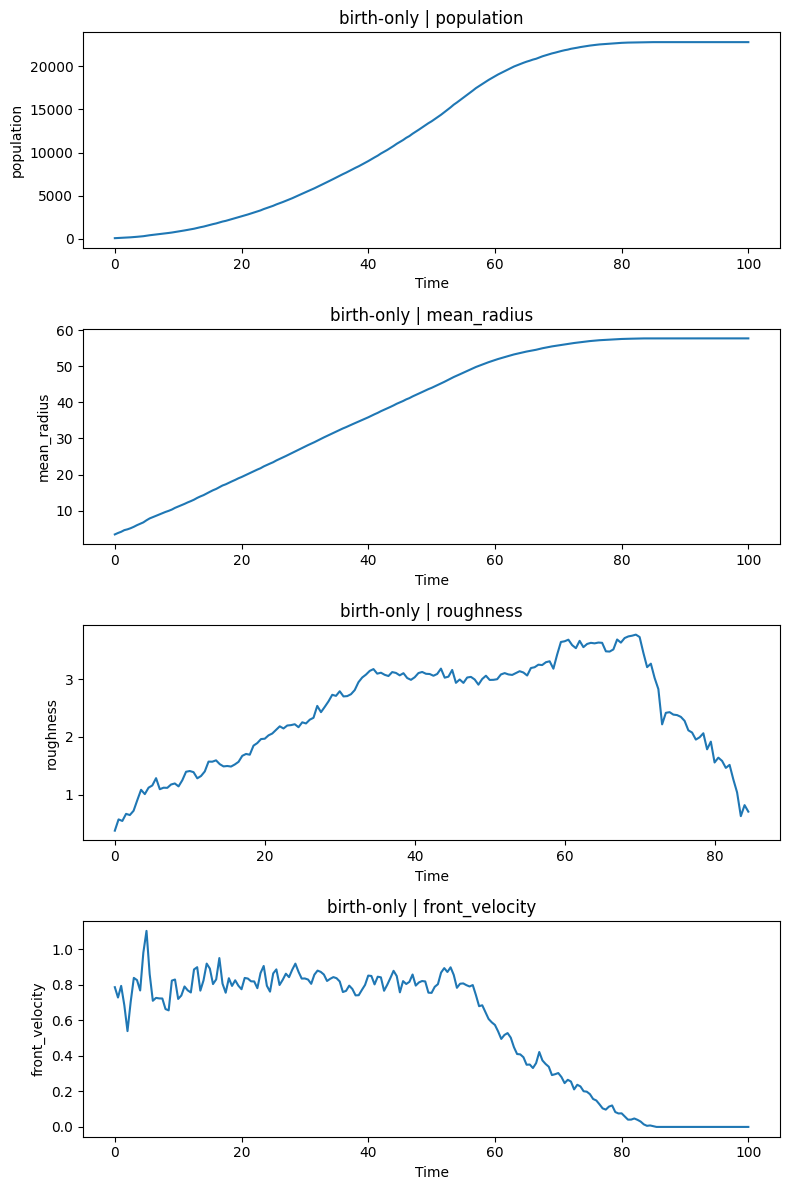

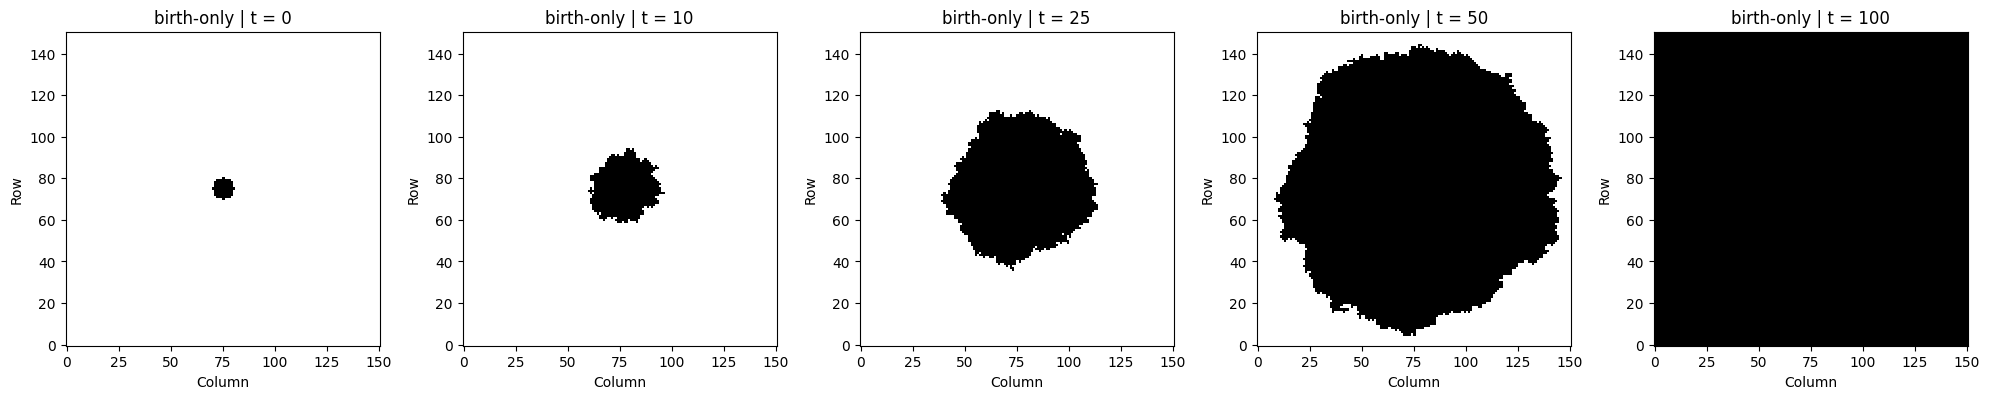

In [3]:
# ============= OPTIMIZED (NEW) - BIS =============
# ----------------------------
# Geometry and initialization
# ----------------------------
lattice = make_lattice(kind="square", nrows=151, ncols=151, periodic=False)
initial_state = lattice.make_disk_state(radius=5.0)

# ----------------------------
# Model configuration
# ----------------------------
config = ModelConfig(
    birth_kernel=make_birth_kernel("cell_driven"),
    r_birth=1.0,
    r_death=0.0,
    birth_modifier=NoAdhesion(),
    death_modifier=NoAdhesion(),
)

# ----------------------------
# Simulation
# ----------------------------
simulator = CultureSimulator(lattice=lattice)

t_final = 100.0
observation_times = np.linspace(0.0, t_final, 201)

result = simulator.run(
    initial_state=initial_state,
    config=config,
    t_final=t_final,
    rng=np.random.default_rng(12345),
    observation_times=observation_times,
    store_snapshots=True,
)

plot_observables(result, title_prefix="birth-only | ")
plot_snapshots(lattice, result, times_to_show=[0.0, 10.0, 25.0, 50.0, 100.0], title_prefix="birth-only | ")

## Front-growth exponent

In [4]:
fit_radius = fit_power_law_exponent(
    times=result.times,
    values=result.mean_radius,
    t_min=5.0,
    t_max=60.0,
)

fit_roughness = fit_power_law_exponent(
    times=result.times,
    values=result.roughness,
    t_min=5.0,
    t_max=70.0,
)

print("Mean-radius exponent fit:")
print(fit_radius)

print("\nRoughness exponent fit:")
print(fit_roughness)

Mean-radius exponent fit:
{'alpha': 0.84077400033639, 'log_C': 0.4602458626897484, 'C': 1.5844634975665353, 'r2_loglog': 0.9966206108392861, 'n_points': 111}

Roughness exponent fit:
{'alpha': 0.404530850466948, 'log_C': -0.6660669429025106, 'C': 0.5137251198282672, 'r2_loglog': 0.9302671712123008, 'n_points': 131}


## Birth-death

In [5]:
gamma = 2.0
r_birth = 1.0
r_death = r_birth / gamma

config_bd = ModelConfig(
    birth_kernel=make_birth_kernel("cell_driven"),  # empty_driven
    r_birth=r_birth,
    r_death=r_death,
    birth_modifier=NoAdhesion(),
    death_modifier=NoAdhesion(),
)

result_bd = simulator.run(
    initial_state=initial_state,
    config=config_bd,
    t_final=100.0,
    rng=np.random.default_rng(2026),
    observation_times=observation_times,
    store_snapshots=False,
)

plot_observables(
    result_bd,
    which=("population", "density", "mean_radius", "roughness", "front_velocity"),
    title_prefix="birth-death | ",
)

KeyboardInterrupt: 

## Adhesion example on births only

In [ ]:
config_adh = ModelConfig(
    birth_kernel=make_birth_kernel("empty_driven"),
    r_birth=1.0,
    r_death=0.2,
    birth_modifier=BoltzmannModifier(beta=0.8),   # try also PowerLawModifier(alpha=2.0)
    death_modifier=NoAdhesion(),
)

result_adh = simulator.run(
    initial_state=initial_state,
    config=config_adh,
    t_final=100.0,
    rng=np.random.default_rng(31415),
    observation_times=observation_times,
    store_snapshots=True,
)

plot_observables(result_adh, title_prefix="adhesion-on-births | ")
plot_snapshots(lattice, result_adh, times_to_show=[0.0, 10.0, 25.0, 50.0, 100.0], title_prefix="adhesion | ")

## Ensemble helper for experiment 2

In [ ]:
def run_ensemble(
    lattice_kind: str,
    update_source: str,
    r_birth: float,
    r_death: float,
    birth_modifier,
    death_modifier,
    nrows: int,
    ncols: int,
    seed_radius: float,
    t_final: float,
    n_runs: int,
    base_seed: int,
):
    lattice = make_lattice(kind=lattice_kind, nrows=nrows, ncols=ncols, periodic=False)
    simulator = CultureSimulator(lattice=lattice)
    initial_state = lattice.make_disk_state(radius=seed_radius)
    observation_times = np.linspace(0.0, t_final, 201)

    results = []
    for i in range(n_runs):
        config = ModelConfig(
            birth_kernel=make_birth_kernel(update_source),
            r_birth=r_birth,
            r_death=r_death,
            birth_modifier=birth_modifier,
            death_modifier=death_modifier,
        )

        rng = np.random.default_rng(base_seed + i)

        result = simulator.run(
            initial_state=initial_state,
            config=config,
            t_final=t_final,
            rng=rng,
            observation_times=observation_times,
            store_snapshots=False,
        )
        results.append(result)

    return lattice, results

## Ensemble aggregation example

In [ ]:
lattice, results = run_ensemble(
    lattice_kind="square",
    update_source="cell_driven",
    r_birth=1.0,
    r_death=0.5,
    birth_modifier=NoAdhesion(),
    death_modifier=NoAdhesion(),
    nrows=151,
    ncols=151,
    seed_radius=5.0,
    t_final=100.0,
    n_runs=20,
    base_seed=1000,
)

agg = aggregate_results(results)

plot_ensemble_curve(
    agg_df=agg,
    y="mean_population",
    y_std="std_population",
    title="Mean population",
)

plot_ensemble_curve(
    agg_df=agg,
    y="survival_probability",
    title="Survival probability",
)

plot_ensemble_curve(
    agg_df=agg,
    y="mean_density",
    y_std="std_density",
    title="Mean density",
)

## 